In [1]:
import pymc as pm, polars as pl, arviz as az

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [11]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Hurricanes.csv", separator=";").with_columns(
    damage_norm = pl.col("damage_norm")/pl.col("damage_norm").max(),
)

df = standardize_columns(df, columns=["femininity", "min_pressure"])

In [16]:
with pm.Model() as model_pressure:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())
    min_pressure = pm.Data("min_pressure", df["min_pressure"].to_numpy())
    damage_norm = pm.Data("damage_norm", df["damage_norm"].to_numpy())

    # alpha for negative_binomial
    alpha_dispersion = pm.Exponential("alpha_dispersion", 0.5)

    # linear model terms
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_femininity = pm.Normal("beta_femininity", mu=0, sigma=1)
    beta_interaction_pressure = pm.Normal("beta_interaction_pressure", mu=0, sigma=0.3)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha
                                                                    + beta_femininity*femininity
                                                                    + beta_interaction_pressure*min_pressure*femininity
                                                                    #+ beta_interaction_dmg*damage_norm*femininity
                                                                    )
                                      )

    deaths = pm.NegativeBinomial("deaths", mu=expected_count, alpha=alpha_dispersion, observed = df["deaths"].to_numpy())

    # sample å
    posterior_pressure = pm.sample(chains=4)
    pm.compute_log_likelihood(posterior_pressure)

with pm.Model() as model_dmg:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())
    min_pressure = pm.Data("min_pressure", df["min_pressure"].to_numpy())
    damage_norm = pm.Data("damage_norm", df["damage_norm"].to_numpy())

    # alpha for negative_binomial
    alpha_dispersion = pm.Exponential("alpha_dispersion", 0.5)

    # linear model terms
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_femininity = pm.Normal("beta_femininity", mu=0, sigma=1)
    beta_interaction_dmg = pm.Normal("beta_interaction_dmg", mu=0, sigma=0.3)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha
                                                                    + beta_femininity*femininity
                                                                    + beta_interaction_dmg*damage_norm*femininity
                                                                    )
                                      )

    deaths = pm.NegativeBinomial("deaths", mu=expected_count, alpha=alpha_dispersion, observed = df["deaths"].to_numpy())

    # sample å
    posterior_dmg = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior_dmg)
    pm.compute_log_likelihood(posterior_dmg)

with pm.Model() as model_both:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())
    min_pressure = pm.Data("min_pressure", df["min_pressure"].to_numpy())
    damage_norm = pm.Data("damage_norm", df["damage_norm"].to_numpy())

    # alpha for negative_binomial
    alpha_dispersion = pm.Exponential("alpha_dispersion", 0.5)

    # linear model terms
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_femininity = pm.Normal("beta_femininity", mu=0, sigma=1)
    beta_interaction_pressure = pm.Normal("beta_interaction_pressure", mu=0, sigma=0.3)
    beta_interaction_dmg = pm.Normal("beta_interaction_dmg", mu=0, sigma=0.3)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha
                                                                    + beta_femininity*femininity
                                                                    + beta_interaction_pressure*min_pressure*femininity
                                                                    + beta_interaction_dmg*damage_norm*femininity
                                                                    )
                                      )

    deaths = pm.NegativeBinomial("deaths", mu=expected_count, alpha=alpha_dispersion, observed = df["deaths"].to_numpy())

    # sample å
    posterior_both = pm.sample(chains=4)
    pm.compute_log_likelihood(posterior_both)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_dispersion, alpha, beta_femininity, beta_interaction_pressure]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_dispersion, alpha, beta_femininity, beta_interaction_dmg]


...

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_dispersion, alpha, beta_femininity, beta_interaction_pressure, beta_interaction_dmg]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Output()

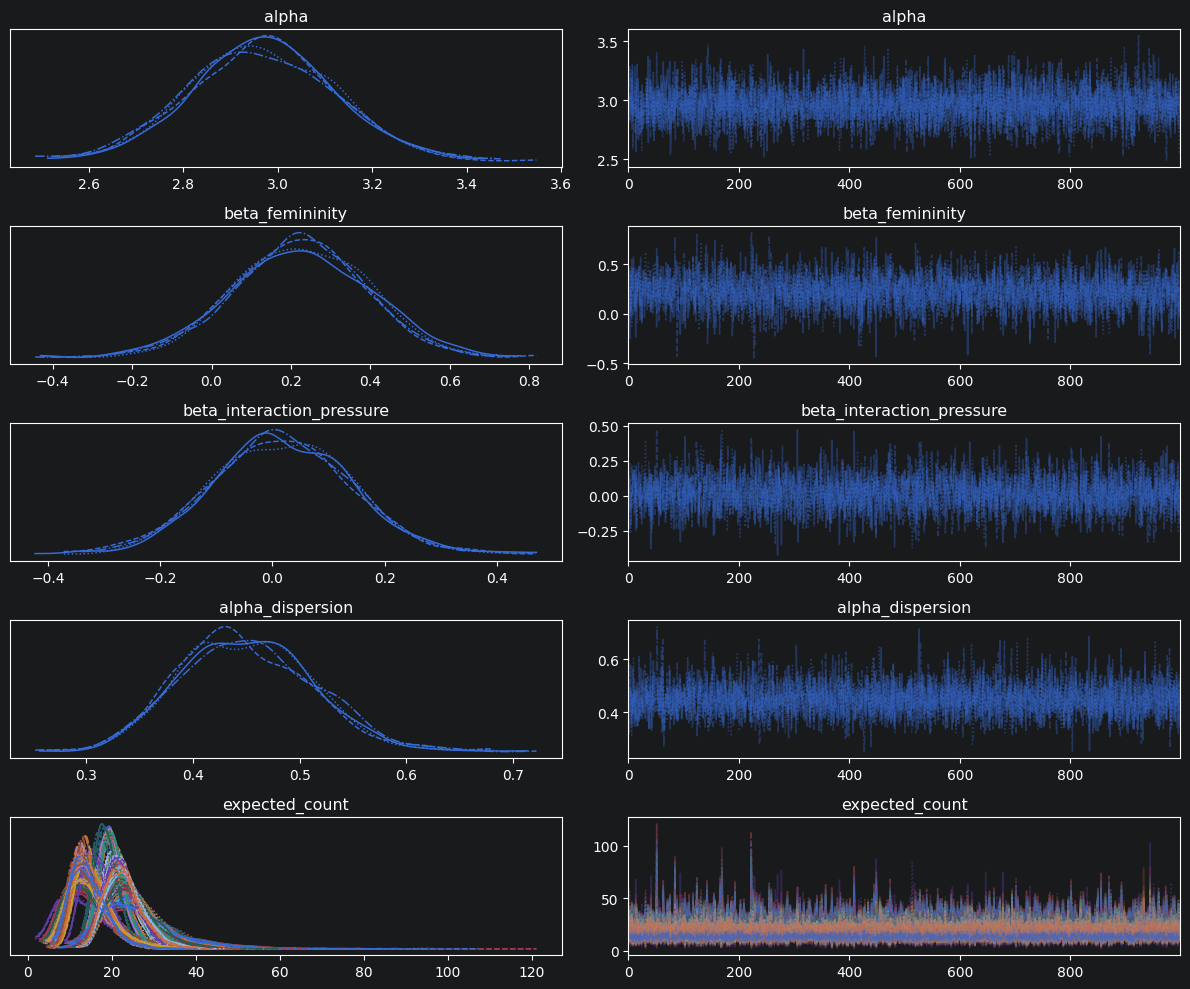

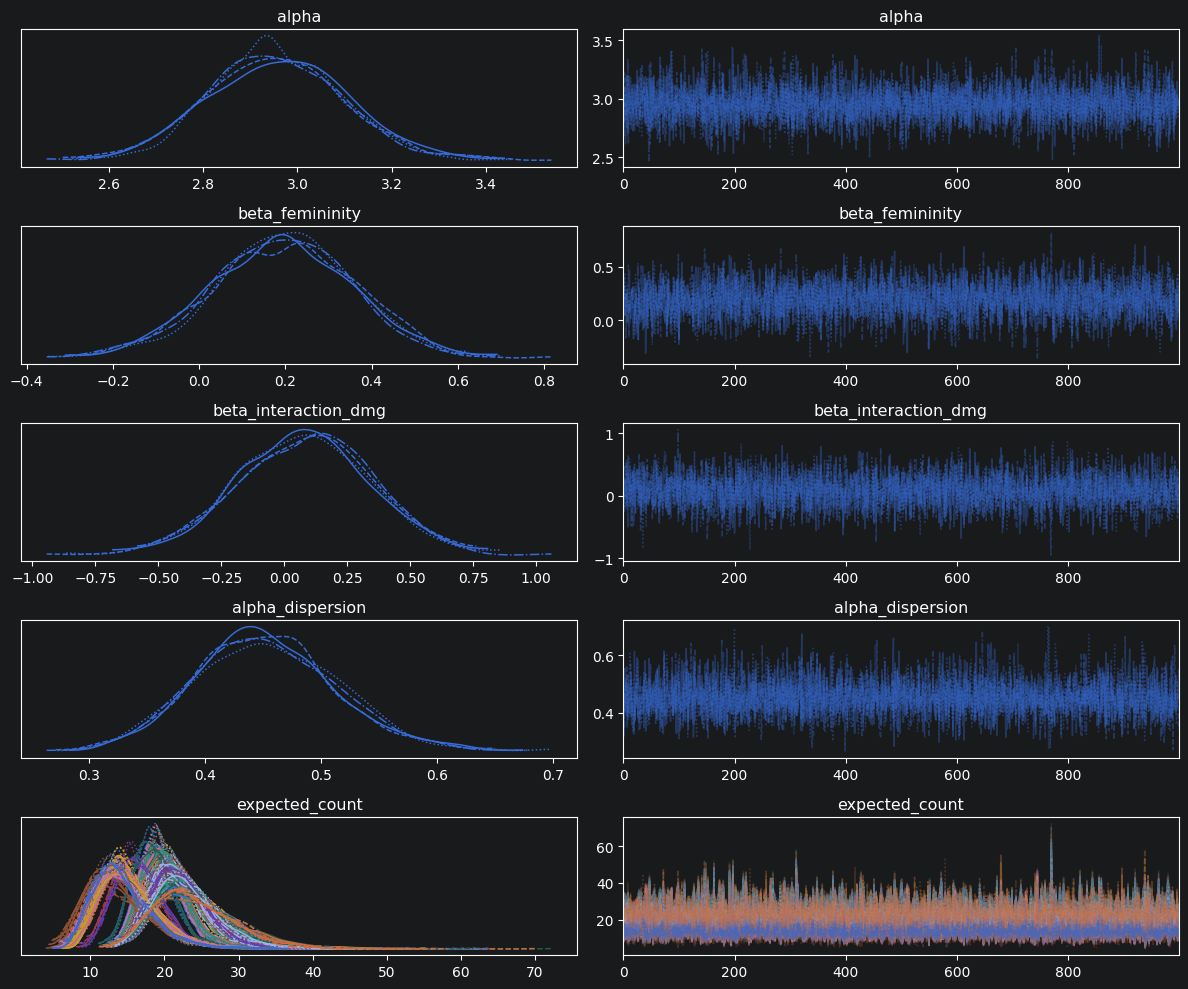

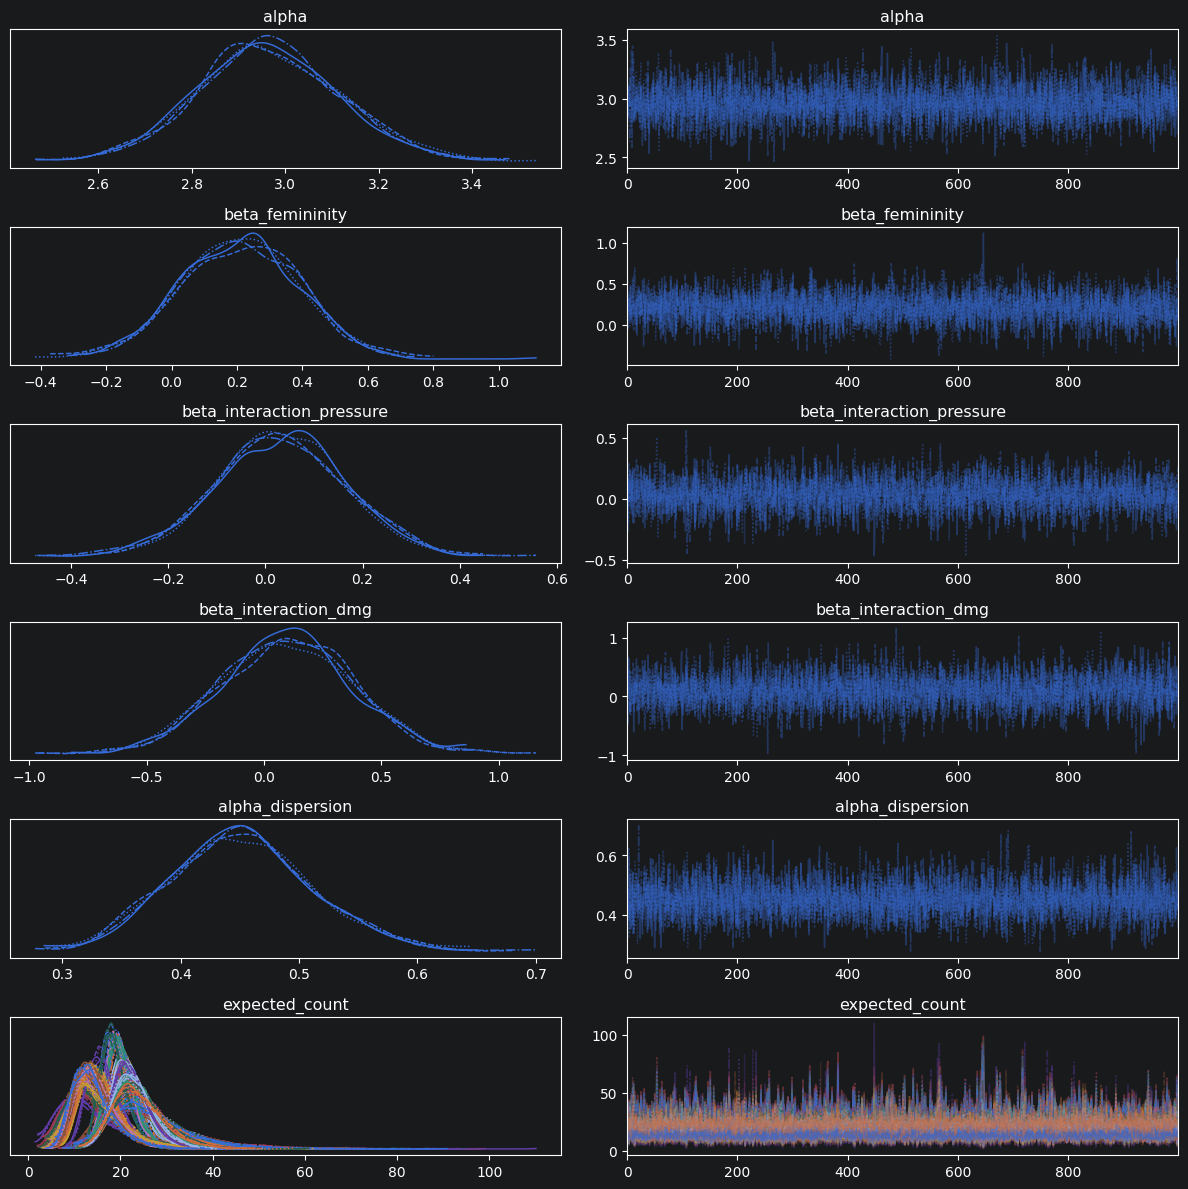

In [13]:
for posterior in (posterior_pressure, posterior_dmg, posterior_both):
    plot_trace(posterior)

In [14]:
comparison = az.compare({
    "pressure_interaction": posterior_pressure,
    "dmg_interaction": posterior_dmg,
    "both_interaction": posterior_both,
}, scale="deviance")
comparison

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
dmg_interaction,0,710.081355,3.992783,0.000000,1.000000e+00,33.041706,0.000000,False,deviance
pressure_interaction,1,714.129678,6.269674,4.048323,0.000000e+00,34.403827,2.608032,True,deviance
both_interaction,2,715.393767,7.095279,5.312412,5.107026e-15,34.977826,3.607053,True,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

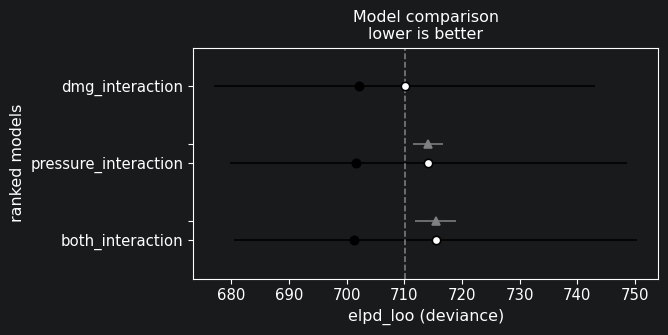

In [15]:
az.plot_compare(comparison, plot_ic_diff=True, insample_dev=True)

Sampling: [deaths]


Output()

<Axes: >

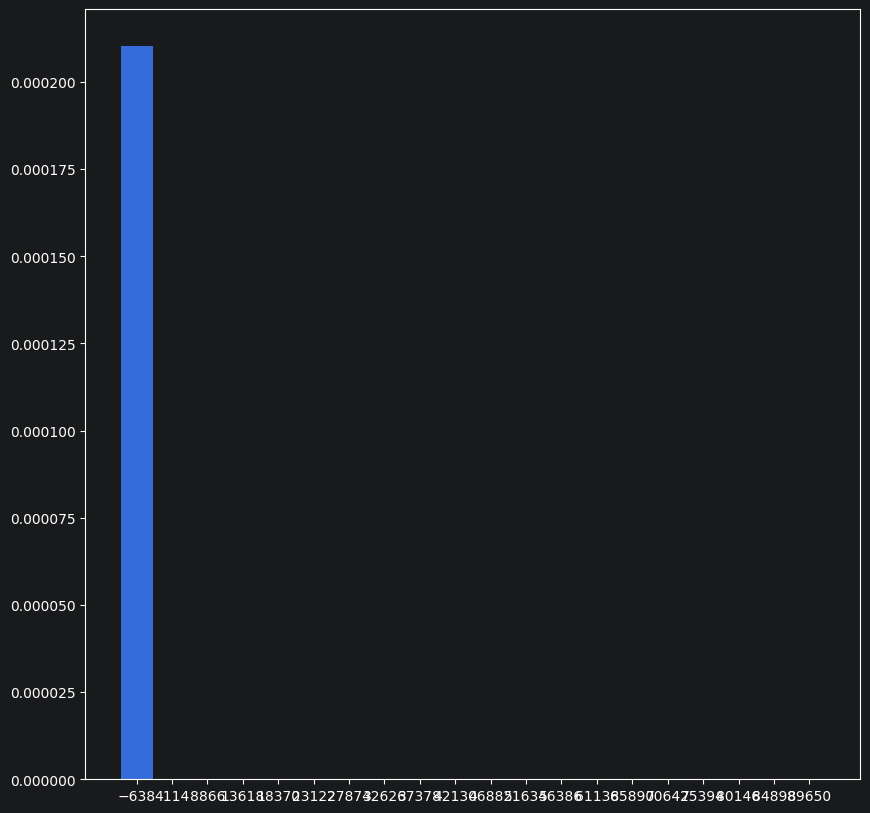

In [32]:
with model_dmg:
    pm.set_data({"femininity": df["femininity"].to_numpy() + 3,
                 "damage_norm": df["damage_norm"].to_numpy() + 1,})
    cf_posterior_predictive = pm.sample_posterior_predictive(posterior_dmg)

az.plot_dist((cf_posterior_predictive.posterior_predictive - posterior_predictive.posterior_predictive).deaths,
             figsize=(10,10))